Mounting my drive and setting paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE      = '/content/drive/MyDrive/Landslide Project'
TASK1_DIR = f'{BASE}/outputs/task1'
TASK2_DIR = f'{BASE}/outputs/task2'
VEL_PATH  = f'{BASE}/data/insar/los_velocity.tif'
COH_PATH  = f'{BASE}/data/insar/coherence.tif'

import os
os.makedirs(TASK2_DIR, exist_ok=True)
print('Drive mounted and paths set!')

Mounted at /content/drive
Drive mounted and paths set!


Installing and Importing all libraries

In [3]:
!pip install rasterio matplotlib numpy -q

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries ready!')

Libraries ready!


In [4]:
# Load LOS Velocity
with rasterio.open(VEL_PATH) as src:
    velocity    = src.read(1).astype(float)
    vel_profile = src.profile
    vel_nodata  = src.nodata
    print(f'Velocity shape:  {velocity.shape}')
    print(f'Velocity CRS:    {src.crs}')
    print(f'Velocity nodata: {vel_nodata}')
    print(f'Velocity range:  {velocity.min():.3f} to {velocity.max():.3f}')

print()

# Load Coherence
with rasterio.open(COH_PATH) as src:
    coherence   = src.read(1).astype(float)
    coh_profile = src.profile
    print(f'Coherence shape:  {coherence.shape}')
    print(f'Coherence CRS:    {src.crs}')
    print(f'Coherence range:  {coherence.min():.3f} to {coherence.max():.3f}')

Velocity shape:  (2689, 3928)
Velocity CRS:    EPSG:4326
Velocity nodata: None
Velocity range:  nan to nan

Coherence shape:  (2689, 3928)
Coherence CRS:    EPSG:4326
Coherence range:  0.000 to 254.000


In [5]:
# Replace nodata with NaN
if vel_nodata is not None:
    velocity[velocity == vel_nodata] = np.nan

# Coherence should be between 0 and 1
coherence[coherence < 0]   = np.nan
coherence[coherence > 1]   = np.nan

print(f'Valid velocity pixels:   {(~np.isnan(velocity)).sum():,}')
print(f'Valid coherence pixels:  {(~np.isnan(coherence)).sum():,}')
print(f'Velocity range (clean):  {np.nanmin(velocity):.3f} to {np.nanmax(velocity):.3f} mm/yr')
print(f'Coherence range (clean): {np.nanmin(coherence):.3f} to {np.nanmax(coherence):.3f}')

Valid velocity pixels:   7,837,768
Valid coherence pixels:  3,366,486
Velocity range (clean):  -16.929 to -11.580 mm/yr
Coherence range (clean): 0.000 to 0.000


In [6]:
COH_THRESHOLD = 0.3  # standard threshold for landslide studies

# Create mask — True where coherence is too low
coh_mask = coherence < COH_THRESHOLD

# Apply mask to velocity
velocity_masked = velocity.copy()
velocity_masked[coh_mask] = np.nan

print(f'Coherence threshold:     {COH_THRESHOLD}')
print(f'Pixels masked:           {coh_mask.sum():,}')
print(f'Pixels retained:         {(~coh_mask).sum():,}')
print(f'Masking percentage:      {coh_mask.mean()*100:.1f}%')
print(f'Masked velocity range:   {np.nanmin(velocity_masked):.3f} to {np.nanmax(velocity_masked):.3f} mm/yr')

Coherence threshold:     0.3
Pixels masked:           3,366,486
Pixels retained:         7,195,906
Masking percentage:      31.9%
Masked velocity range:   -16.856 to -11.736 mm/yr


In [7]:
# Save masked velocity
vel_masked_path = f'{TASK2_DIR}/los_velocity_masked.tif'

vel_profile.update(dtype='float32', nodata=-9999)
vel_out = np.where(np.isnan(velocity_masked), -9999, velocity_masked)

with rasterio.open(vel_masked_path, 'w', **vel_profile) as dst:
    dst.write(vel_out.astype('float32'), 1)

# Save coherence mask
coh_masked_path = f'{TASK2_DIR}/coherence_masked.tif'
coh_profile.update(dtype='float32', nodata=-9999)
coh_out = np.where(np.isnan(coherence), -9999, coherence)

with rasterio.open(coh_masked_path, 'w', **coh_profile) as dst:
    dst.write(coh_out.astype('float32'), 1)

print('Masked velocity saved!')
print('Coherence saved!')

Masked velocity saved!
Coherence saved!


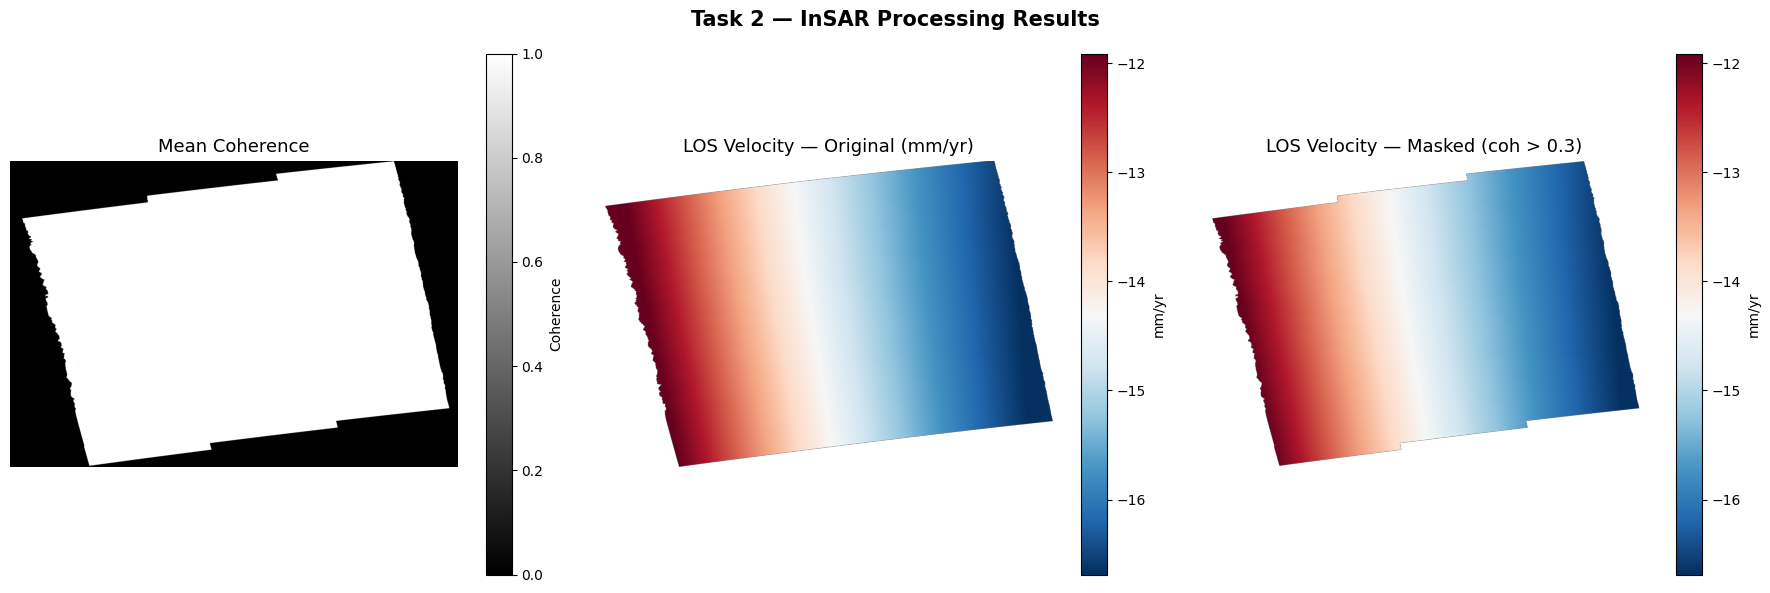

Task 2 maps saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Coherence
im0 = axes[0].imshow(coherence, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Mean Coherence', fontsize=13)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], label='Coherence')

# Original velocity
vmin = np.nanpercentile(velocity, 2)
vmax = np.nanpercentile(velocity, 98)
im1  = axes[1].imshow(velocity, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[1].set_title('LOS Velocity — Original (mm/yr)', fontsize=13)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], label='mm/yr')

# Masked velocity
im2 = axes[2].imshow(velocity_masked, cmap='RdBu_r', vmin=vmin, vmax=vmax)
axes[2].set_title(f'LOS Velocity — Masked (coh > {COH_THRESHOLD})', fontsize=13)
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], label='mm/yr')

plt.suptitle('Task 2 — InSAR Processing Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{TASK2_DIR}/task2_insar_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Task 2 maps saved!')

In [9]:
from rasterio.warp import reproject, Resampling

# Use slope as reference grid
with rasterio.open(f'{TASK1_DIR}/slope_aligned.tif') as ref:
    ref_profile   = ref.profile.copy()
    ref_transform = ref.transform
    ref_crs       = ref.crs
    ref_height    = ref.height
    ref_width     = ref.width

print('Aligning InSAR to Task 1 grid...')

for src_path, name in [
    (vel_masked_path, 'insar_velocity'),
    (coh_masked_path, 'insar_coherence')
]:
    dst_path = f'{TASK1_DIR}/{name}_aligned.tif'
    with rasterio.open(src_path) as src:
        data = np.zeros((1, ref_height, ref_width), dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )
    out_profile = ref_profile.copy()
    out_profile.update(dtype='float32', count=1, nodata=-9999)
    with rasterio.open(dst_path, 'w', **out_profile) as dst:
        dst.write(data[0], 1)
    print(f'Aligned and saved: {name}')

print('Task 2 complete!')

Aligning InSAR to Task 1 grid...
Aligned and saved: insar_velocity
Aligned and saved: insar_coherence
Task 2 complete!
